# Manual Decision Rules - Stage 1 of the Router Simulation

**Input:** `unsw_cleaned_features.csv` (2,059,414 rows x 42 columns).

The router simulation (Part 2 of the project) needs a fast pre-check that runs before the trained ML model: for the easy, high-confidence cases, decide the action directly from simple column checks; only hand the genuinely uncertain cases to the model. This notebook works out **exactly which columns belong in that manual rule, which don't, and why** - with the real numbers and charts behind every decision, not just an assertion.

**Candidates considered:** the 6 columns excluded from the model's `X` in notebook 03 - `swin`, `proto`, `service`, `Spkts`, `sbytes`, `sttl`.

## Contents

1. Setup
2. Why `proto` / `swin` / `service` are excluded from the manual rule
3. Why `sbytes` is excluded - redundant with `Spkts`
4. Why `sttl` is included - real refinement on top of `Spkts`
5. Building the cascade - `Spkts`, then `sttl` within each `Spkts` zone
6. Final 5-zone decision table
7. Zone -> action mapping
8. How sure are we these are the *right* percentages? (95% confidence intervals)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = 'unsw_cleaned_features.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
target_col = 'packet_lost'

print('Shape:', df.shape)

Shape: (2059414, 42)


## Section 2 - Why `proto` / `swin` / `service` are excluded from the manual rule

All three look like they'd make a perfect rule - loss rate swings from ~0% to ~100% depending on their value. The problem is *why*: this dataset's loss counters (`sloss`/`dloss`) can only be measured on TCP traffic at all (UDP/ARP/etc. have no sequence numbers, so the capture tool always logs 0 loss for them - not because those packets are actually safe, but because it can't tell). A rule built on these would tell the simulation "non-TCP traffic never needs protection," which is false in real networking and would directly contradict a realistic loss model in the simulation's own ground truth.

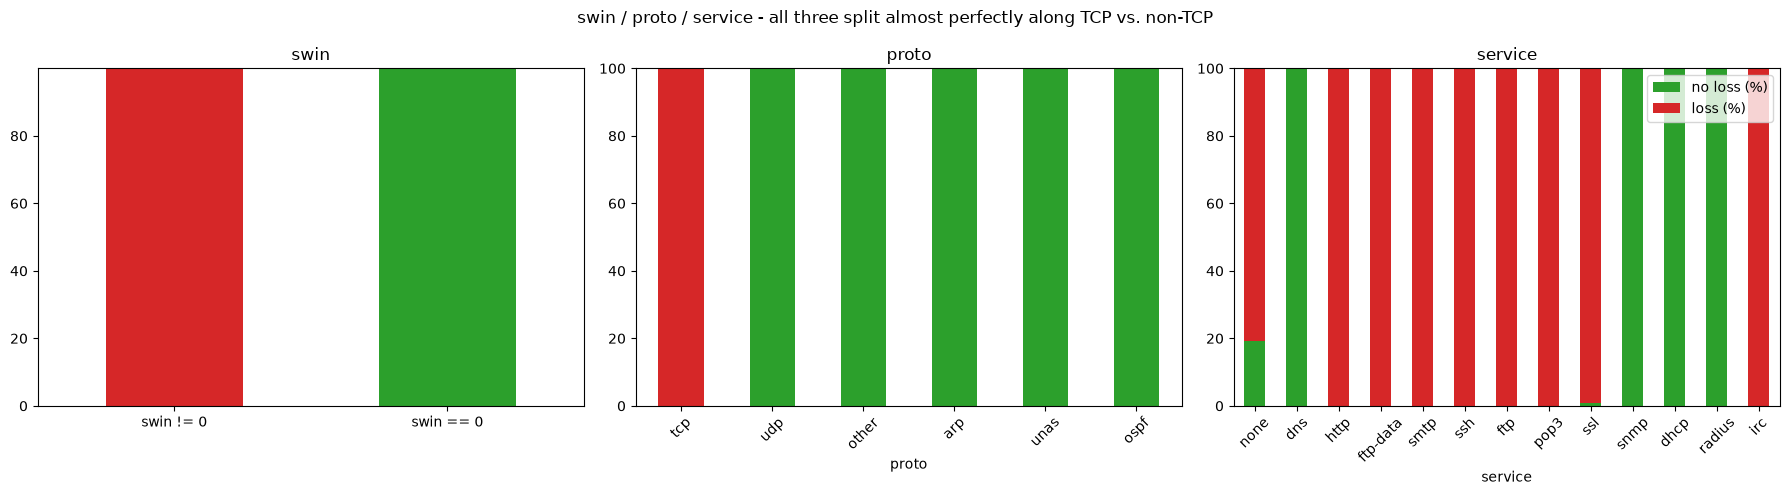

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

swin_ct = pd.crosstab(df['swin'] == 0, df[target_col], normalize='index') * 100
swin_ct.index = ['swin != 0', 'swin == 0']
swin_ct.columns = ['no loss (%)', 'loss (%)']
swin_ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ca02c', '#d62728'], legend=False)
axes[0].set_title('swin')
axes[0].tick_params(axis='x', rotation=0)

proto_ct = pd.crosstab(df['proto'], df[target_col], normalize='index') * 100
proto_ct.columns = ['no loss (%)', 'loss (%)']
proto_ct = proto_ct.loc[df['proto'].value_counts().index]
proto_ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ca02c', '#d62728'], legend=False)
axes[1].set_title('proto')
axes[1].tick_params(axis='x', rotation=45)

service_ct = pd.crosstab(df['service'], df[target_col], normalize='index') * 100
service_ct.columns = ['no loss (%)', 'loss (%)']
service_ct = service_ct.loc[df['service'].value_counts().index]
service_ct.plot(kind='bar', stacked=True, ax=axes[2], color=['#2ca02c', '#d62728'])
axes[2].set_title('service')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('swin / proto / service - all three split almost perfectly along TCP vs. non-TCP')
plt.tight_layout()
plt.show()

**Excluded from the manual rule** - all three, for the same root cause.

## Section 3 - Why `sbytes` is excluded - redundant with `Spkts`

`sbytes` and `Spkts` both describe the same thing - how much this flow has sent so far. If `sbytes` doesn't add anything once `Spkts` is already known, there's no reason to check both in the manual rule.

Correlation, Spkts vs sbytes: 0.62


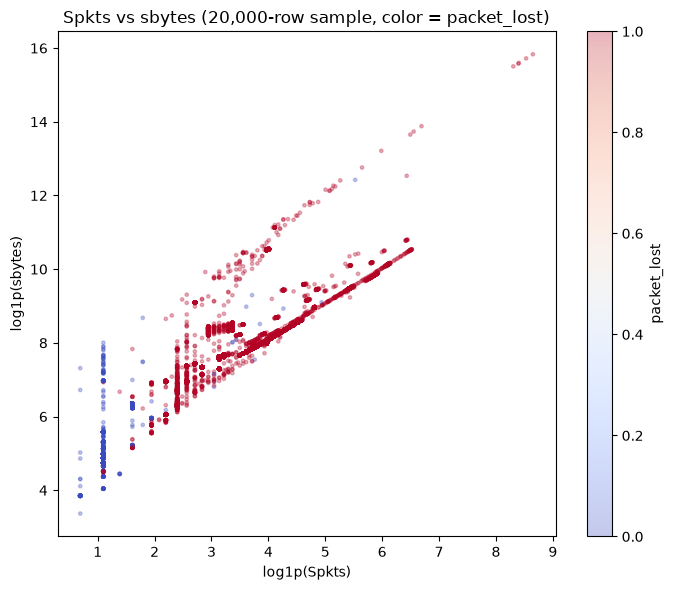

In [3]:
print('Correlation, Spkts vs sbytes:', round(df['Spkts'].corr(df['sbytes']), 3))

sample = df.sample(20_000, random_state=42)
plt.figure(figsize=(7, 6))
plt.scatter(np.log1p(sample['Spkts']), np.log1p(sample['sbytes']), s=6, alpha=0.3, c=sample[target_col], cmap='coolwarm')
plt.xlabel('log1p(Spkts)')
plt.ylabel('log1p(sbytes)')
plt.title('Spkts vs sbytes (20,000-row sample, color = packet_lost)')
plt.colorbar(label='packet_lost')
plt.tight_layout()
plt.show()

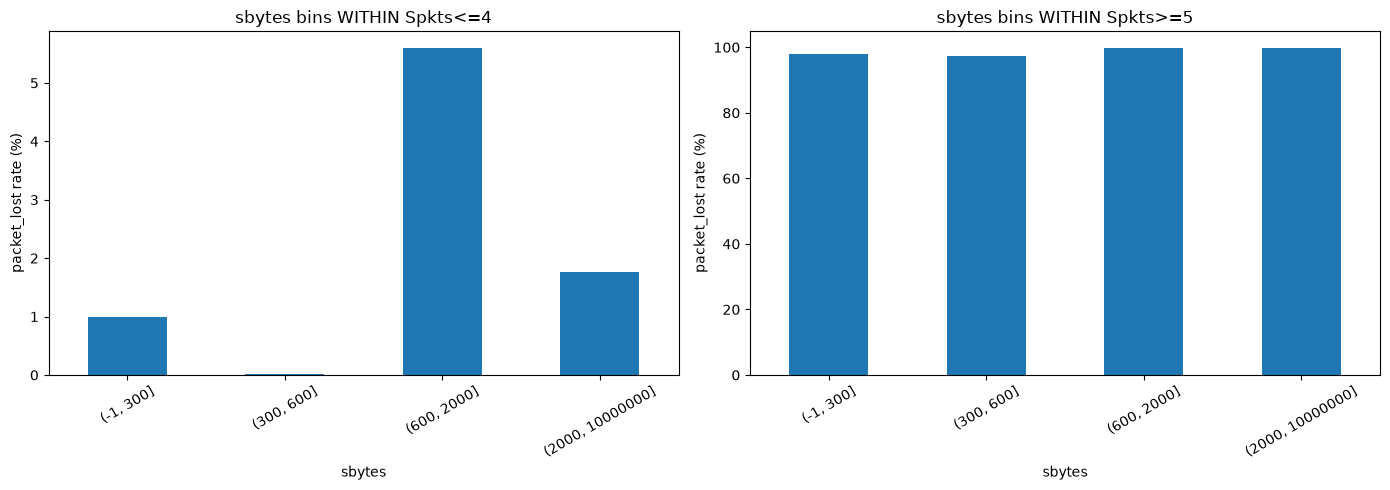

In [4]:
spkts_zone = pd.cut(df['Spkts'], bins=[-1, 4, 100000], labels=['Spkts<=4', 'Spkts>=5'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, zone in zip(axes, ['Spkts<=4', 'Spkts>=5']):
    sub = df[spkts_zone == zone]
    g = sub.groupby(pd.cut(sub['sbytes'], bins=[-1, 300, 600, 2000, 10_000_000]))[target_col].mean() * 100
    g.plot(kind='bar', ax=ax, color='#1f77b4')
    ax.set_ylabel('packet_lost rate (%)')
    ax.set_title(f'sbytes bins WITHIN {zone}')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Once `Spkts` is known, `sbytes` bins don't move the loss rate in any consistent direction - it bounces around within both `Spkts` zones instead of climbing smoothly. **Excluded from the manual rule** - not because it's biased like `proto`/`swin`/`service`, just because it adds nothing on top of `Spkts`.

## Section 4 - Why `sttl` is included - real refinement on top of `Spkts`

Unlike `sbytes`, `sttl` bins inside each `Spkts` zone show a clear, large-sample split - not noise.

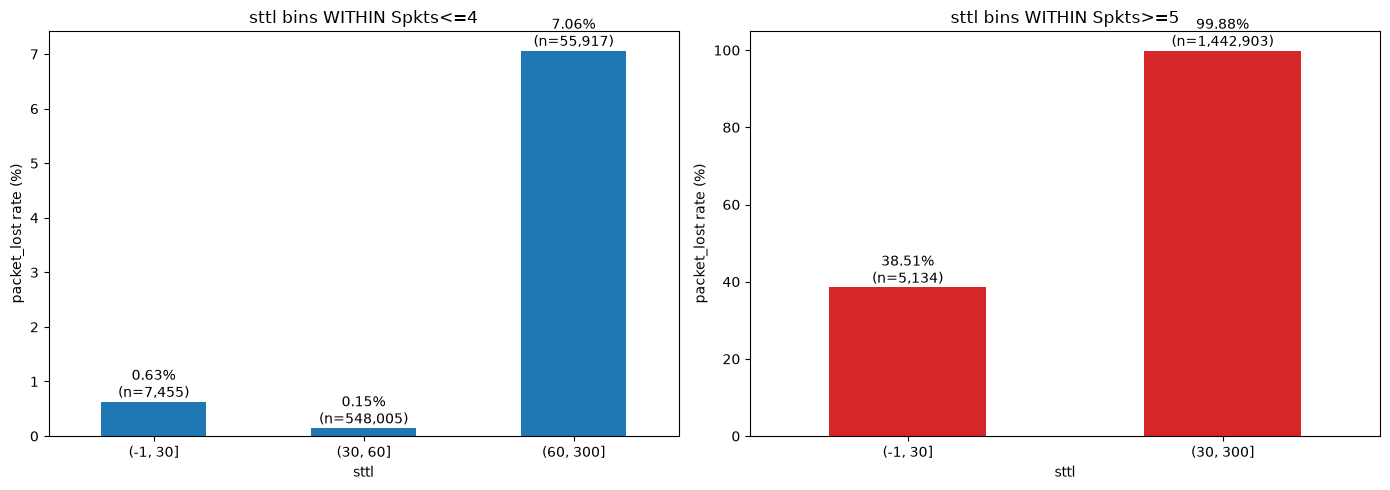

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

low = df[df['Spkts'] <= 4]
g_low = low.groupby(pd.cut(low['sttl'], bins=[-1, 30, 60, 300]))[target_col].agg(['mean', 'count'])
g_low['loss_pct'] = g_low['mean'] * 100
g_low['loss_pct'].plot(kind='bar', ax=axes[0], color='#1f77b4')
for i, (pct, cnt) in enumerate(zip(g_low['loss_pct'], g_low['count'])):
    axes[0].text(i, pct, f'{pct:.2f}%\n(n={cnt:,})', ha='center', va='bottom')
axes[0].set_ylabel('packet_lost rate (%)')
axes[0].set_title('sttl bins WITHIN Spkts<=4')
axes[0].tick_params(axis='x', rotation=0)

high = df[df['Spkts'] >= 5]
g_high = high.groupby(pd.cut(high['sttl'], bins=[-1, 30, 300]))[target_col].agg(['mean', 'count'])
g_high['loss_pct'] = g_high['mean'] * 100
g_high['loss_pct'].plot(kind='bar', ax=axes[1], color='#d62728')
for i, (pct, cnt) in enumerate(zip(g_high['loss_pct'], g_high['count'])):
    axes[1].text(i, pct, f'{pct:.2f}%\n(n={cnt:,})', ha='center', va='bottom')
axes[1].set_ylabel('packet_lost rate (%)')
axes[1].set_title('sttl bins WITHIN Spkts>=5')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Both zones split cleanly on `sttl`, on samples in the tens of thousands to over a million - not noise. **Included in the manual rule.**

Final check: `Spkts` and `sttl` shouldn't be redundant with each other, the way `Spkts` and `sbytes` were.

In [6]:
print('Correlation, Spkts vs sttl:', round(df['Spkts'].corr(df['sttl']), 3))

Correlation, Spkts vs sttl: -0.077


Near zero - `sttl` is telling the rule something `Spkts` doesn't already know, which is exactly why combining them works.

## Section 5 - Building the cascade

Step 1: split on `Spkts` (the strongest single column, from notebook 03's Section 10g).

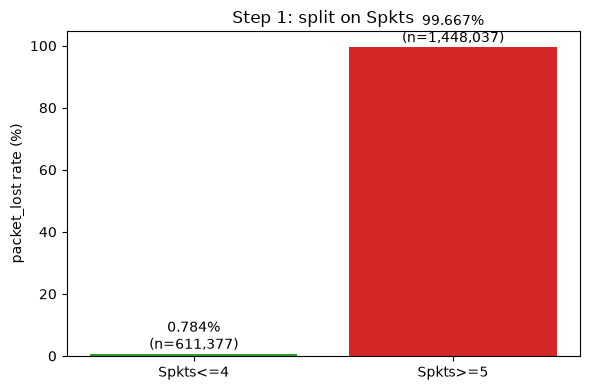

In [7]:
spkts_bins = df.groupby(pd.cut(df['Spkts'], bins=[-1, 4, 100000], labels=['Spkts<=4', 'Spkts>=5']))[target_col].agg(['mean', 'count'])
spkts_bins['loss_pct'] = (spkts_bins['mean'] * 100).round(3)

plt.figure(figsize=(6, 4))
plt.bar(spkts_bins.index.astype(str), spkts_bins['loss_pct'], color=['#2ca02c', '#d62728'])
plt.ylabel('packet_lost rate (%)')
plt.title('Step 1: split on Spkts')
for i, (pct, cnt) in enumerate(zip(spkts_bins['loss_pct'], spkts_bins['count'])):
    plt.text(i, pct, f'{pct}%\n(n={cnt:,})', ha='center', va='bottom')
plt.tight_layout()
plt.show()

Step 2: split each `Spkts` zone on `sttl`, using the same bin edges validated in Sections 2-4.

In [8]:
def leaf(sub, sttl_lo, sttl_hi):
    mask = (sub['sttl'] > sttl_lo) & (sub['sttl'] <= sttl_hi)
    part = sub[mask]
    return len(part), part[target_col].mean() * 100

low = df[df['Spkts'] <= 4]
high = df[df['Spkts'] >= 5]

zones = {
    'Spkts<=4 & 30<sttl<=60': leaf(low, 30, 60),
    'Spkts<=4 & sttl<=30': leaf(low, -1, 30),
    'Spkts<=4 & sttl>60': leaf(low, 60, 100000),
    'Spkts>=5 & sttl<=30': leaf(high, -1, 30),
    'Spkts>=5 & sttl>30': leaf(high, 30, 100000),
}

zones_df = pd.DataFrame(zones, index=['count', 'loss_pct']).T
zones_df['loss_pct'] = zones_df['loss_pct'].round(3)
zones_df['count'] = zones_df['count'].astype(int)
print('Row check - zones sum to full dataset:', zones_df['count'].sum(), '==', len(df))
zones_df

Row check - zones sum to full dataset: 2059414 == 2059414


,count,loss_pct
Spkts<=4 & 30<sttl<=60,548005,0.146
Spkts<=4 & sttl<=30,7455,0.630
Spkts<=4 & sttl>60,55917,7.064
Spkts>=5 & sttl<=30,5134,38.508
Spkts>=5 & sttl>30,1442903,99.885


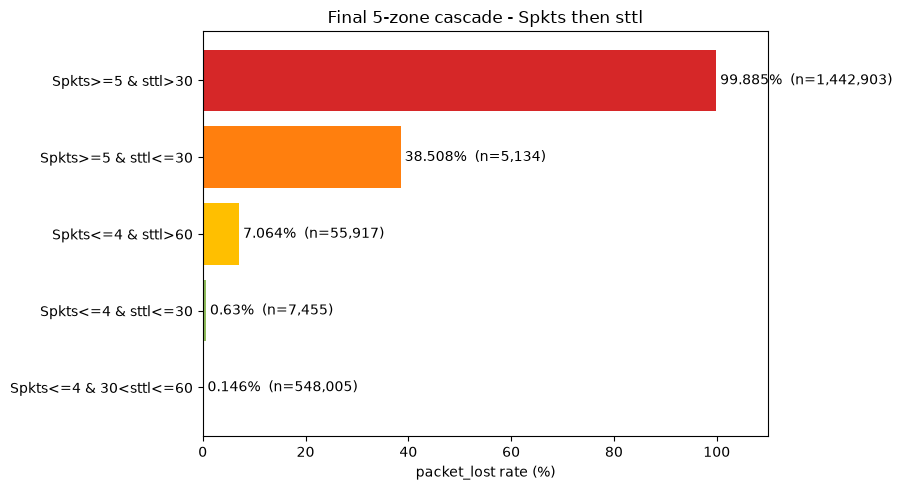

In [9]:
plt.figure(figsize=(9, 5))
colors = ['#2ca02c', '#8fbc5a', '#ffbf00', '#ff7f0e', '#d62728']
bars = plt.barh(zones_df.index, zones_df['loss_pct'], color=colors)
plt.xlabel('packet_lost rate (%)')
plt.title('Final 5-zone cascade - Spkts then sttl')
for bar, pct, cnt in zip(bars, zones_df['loss_pct'], zones_df['count']):
    plt.text(pct, bar.get_y() + bar.get_height()/2, f' {pct}%  (n={cnt:,})', va='center')
plt.xlim(0, 110)
plt.tight_layout()
plt.show()

## Section 6 - Final 5-zone decision table

```python
if   Spkts <= 4 and 30 < sttl <= 60:   r ~ 0.15%    # zone 1
elif Spkts <= 4 and sttl <= 30:        r ~ 0.63%    # zone 2
elif Spkts <= 4 and sttl > 60:         r ~ 7.06%    # zone 3
elif Spkts >= 5 and sttl <= 30:        r ~ 38.51%   # zone 4
else:                                  r ~ 99.89%   # zone 5 (Spkts >= 5 and sttl > 30)
```

Every row in the dataset falls into exactly one of these 5 zones (verified above - the counts sum to the full 2,059,414 rows), and each zone's risk estimate rests on a sample of at least 5,134 rows - none of these numbers come from a handful of noisy examples.

## Section 7 - Zone -> action mapping

| Zone | Condition | r | Action | Needs ML? |
|---|---|---|---|---|
| 1 | `Spkts<=4` & `30<sttl<=60` | ~0.15% | **NO_PROTECTION** - send normally | No |
| 2 | `Spkts<=4` & `sttl<=30` | ~0.63% | **LIGHT** - small manual delay | No |
| 3 | `Spkts<=4` & `sttl>60` | ~7.1% | **MODERATE** | Yes |
| 4 | `Spkts>=5` & `sttl<=30` | ~38.5% | **MODERATE-HIGH** | Yes |
| 5 | `Spkts>=5` & `sttl>30` | ~99.9% | **MAX** | Yes |

Zones 1-2 are resolved entirely by the manual rule - no model call needed. Zones 3-5 hand off to the trained model (notebook 04's Random Forest/XGBoost, using the 10-column `X`) to pick the exact action within that band; the manual zone is the floor, the model's `predict_proba` refines it further using the `ct_*` congestion counters, `smeansz`, and `dst_port_bucket` that `Spkts`/`sttl` alone can't see.

## Section 8 - How sure are we these are the *right* percentages?

A percentage alone doesn't say how trustworthy it is - `r = 38.5%` from 5 rows would be nearly meaningless, but `r = 38.5%` from 5,134 rows is a very different claim. Determining whether a rate reflects the true population value, rather than noise from one particular sample, requires a **95% confidence interval** - the range the true rate almost certainly falls in, given the sample size. More samples -> a narrower range -> more confidence in the exact number reported.

In [10]:
n = zones_df['count'].values
p = (zones_df['loss_pct'].values / 100)
se = np.sqrt(p * (1 - p) / n)  # standard error of a proportion
ci_low = (p - 1.96 * se) * 100
ci_high = (p + 1.96 * se) * 100

ci_df = zones_df.copy()
ci_df['ci_low'] = ci_low.round(4)
ci_df['ci_high'] = ci_high.round(4)
ci_df['ci_width_pts'] = (ci_high - ci_low).round(4)
ci_df

,count,loss_pct,ci_low,ci_high,ci_width_pts
Spkts<=4 & 30<sttl<=60,548005,0.146,0.1359,0.1561,0.0202
Spkts<=4 & sttl<=30,7455,0.630,0.4504,0.8096,0.3592
Spkts<=4 & sttl>60,55917,7.064,6.8516,7.2764,0.4247
Spkts>=5 & sttl<=30,5134,38.508,37.1769,39.8391,2.6622
Spkts>=5 & sttl>30,1442903,99.885,99.8795,99.8905,0.0111


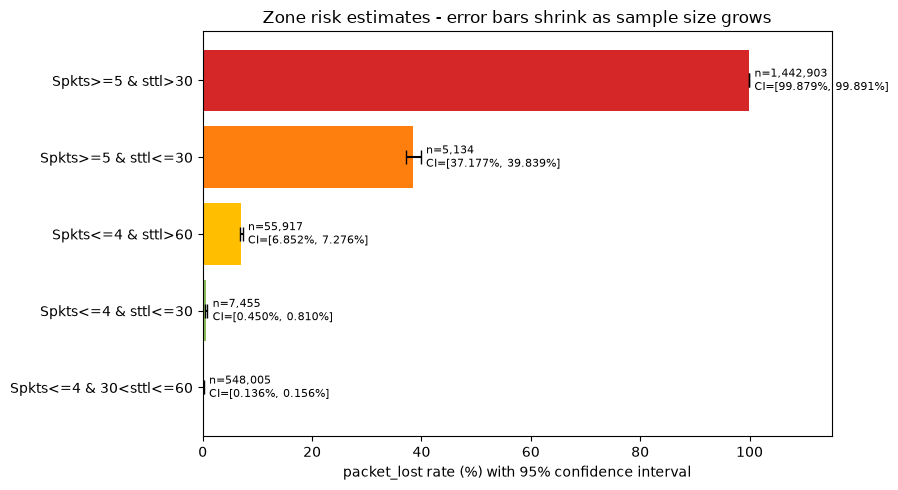

In [11]:
errors = [ci_df['loss_pct'] - ci_df['ci_low'], ci_df['ci_high'] - ci_df['loss_pct']]

plt.figure(figsize=(9, 5))
colors = ['#2ca02c', '#8fbc5a', '#ffbf00', '#ff7f0e', '#d62728']
plt.barh(ci_df.index, ci_df['loss_pct'], xerr=errors, color=colors, capsize=5,
         error_kw={'ecolor': 'black', 'elinewidth': 1.5})
plt.xlabel('packet_lost rate (%) with 95% confidence interval')
plt.title('Zone risk estimates - error bars shrink as sample size grows')
for i, (pct, lo, hi, cnt) in enumerate(zip(ci_df['loss_pct'], ci_df['ci_low'], ci_df['ci_high'], ci_df['count'])):
    plt.text(max(pct, hi) + 1, i, f'n={cnt:,}\nCI=[{lo:.3f}%, {hi:.3f}%]', va='center', fontsize=8)
plt.xlim(0, 115)
plt.tight_layout()
plt.show()

**Conclusion:** each zone's percentage is the observed loss rate over thousands to millions of real rows, and its 95% confidence interval is tight - at most about ±1.3 percentage points (Zone 4, the smallest sample at 5,134 rows), and as narrow as ±0.01 points for the largest zones (Zone 1 and Zone 5, over half a million and 1.4 million rows). Repeating this measurement on a different random sample of the same traffic would almost certainly land inside that tight range - the zone percentages are not an artifact of this one sample.